**nltk-Natural language tool kit**

In [6]:
pip install nltk matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv('data/yelp_reviews.csv')

In [9]:
df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [11]:
df.isnull().sum()

business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
dtype: int64

In [12]:
df = df.drop('type', axis=1)

In [13]:
df['date']=pd.to_datetime(df['date'])

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   business_id  10000 non-null  object        
 1   date         10000 non-null  datetime64[ns]
 2   review_id    10000 non-null  object        
 3   stars        10000 non-null  int64         
 4   text         10000 non-null  object        
 5   user_id      10000 non-null  object        
 6   cool         10000 non-null  int64         
 7   useful       10000 non-null  int64         
 8   funny        10000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 703.3+ KB


In [60]:
df['text'].duplicated().sum()          


np.int64(2)

In [61]:
df[df['text'].duplicated(keep=False)]

,business_id,date,review_id,stars,text,user_id,cool,useful,funny,review_length,month
284,Hf_MFIPi7ZiIWDQodJMzwg,2012-10-25,9l7FzgtZobP81lMwEQy4AA,5,Great service,9VmTOyq01oIUk5zuxOj1GA,0,0,1,13,October
3921,kkBMTNET2xgHCW-cnNwKxA,2012-12-21,M_GC_TG9TpSzMAUQ_TAimw,5,Great service,9VmTOyq01oIUk5zuxOj1GA,0,0,0,13,December
4372,jvvh4Q00Hq2XyIcfmAAT2A,2012-06-16,ivGRamFF3KurE9bjkl6uMw,2,This review is for the chain in general. The l...,KLekdmo4FdNnP0huUhzZNw,0,0,0,1747,June
9677,rIonUa02zMz_ki8eF-Adug,2012-06-16,mutQE6UfjLIpJ8Wozpq5UA,2,This review is for the chain in general. The l...,KLekdmo4FdNnP0huUhzZNw,0,0,0,1747,June


**Finding the length of review's for all text and removing the rows whose review length is less than 6**

In [42]:
df['review_length'] = df['text'].apply(len)

In [38]:
df[df['review_length'] < 6]


,business_id,date,review_id,stars,text,user_id,cool,useful,funny,review_length,month
6450,tbRu-3NR5za1SEZkszcp5Q,2012-01-03,IVoMGfn9QrZ4dATwc9HBcg,3,X,SHcX9hp5RG3-OqsbvissIQ,0,0,0,1,January
6708,KGX7O-_WqOIy9o7u9NOa9A,2011-04-19,EdFx6mNJDfJWP6yDO42cUQ,4,Go,vnSz2VT6s-gdRBjlFDACYg,0,0,0,2,April
7881,jj-K19oswZARMwCQK-b37A,2012-07-25,eAoV5Vuhh1GvDK8FbqNyHQ,3,Meh.,iq46mlqoLmNQzTR1z8oqUA,0,1,0,4,July


In [41]:
df=df[df['review_length'] >= 6].reset_index(drop=True)

  **Finding how many total different business & users are there**

For 9,997 rows of data.For each business how many reviews we got(9,997/4173 =2.64 reviews)
For 9,997 rows of data.For each user how many reviews they gave(9,997/6401 =1.56reviews)


In [44]:
print("Unique businesses:", df['business_id'].nunique())
print("Unique users:", df['user_id'].nunique())

Unique businesses: 4173
Unique users: 6401


In [59]:
df['business_id'].value_counts().describe()

count    4173.000000
mean        2.395639
std         2.935704
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        37.000000
Name: count, dtype: float64

In [57]:
df['business_id'].value_counts().head(10)


business_id
JokKtdXU7zXHcr20Lrk29A    37
ntN85eu27C04nwyPa8IHtw    37
hW0Ne_HTHEAgGF1rAdmR-g    34
WNy1uzcmm_UHmTyR--o5IA    32
VVeogjZya58oiTxK7qUjAQ    31
V1nEpIRmEa1768oj_tuxeQ    30
uKSX1n1RoAzGq4bV8GPHVg    25
SDwYQ6eSu1htn8vHWv128g    25
EWMwV5V9BxNs_U6nNVMeqw    24
-sC66z4SO3tR7nFCjfQwuQ    24
Name: count, dtype: int64

In [51]:
df['user_id'].value_counts().describe()

count    6401.000000
mean        1.561787
std         1.579053
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        38.000000
Name: count, dtype: float64

In [53]:
df['user_id'].value_counts().head(10)

user_id
fczQCSmaWF78toLEmb0Zsw    38
0CMz8YaO3f8xu4KqQgKb9Q    25
90a6z--_CUrl84aCzZyPsg    22
0mqHhdKEdak_A1FBhFNXqA    18
4ozupHULqGyO42s3zNUzOQ    18
wHg1YkCzdZq9WBJOTRgxHQ    17
_PzSNcfrCjeBxSLXRoMmgQ    16
0bNXP9quoJEgyVZu9ipGgQ    16
JgDkCER12uiv4lbpmkZ9VA    15
joIzw_aUiNvBTuGoytrH7g    15
Name: count, dtype: int64

**From above finding in user and business_is's we can see there a  right-skewed**

In [17]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28756\2129286054.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stars', data=df, palette='viridis')


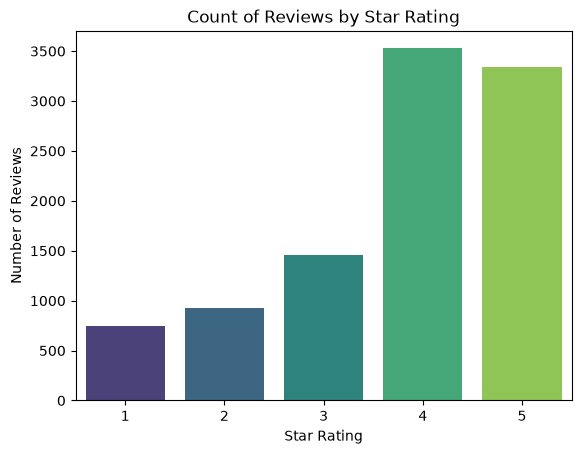

In [19]:
sns.countplot(x='stars', data=df, palette='viridis')
plt.title('Count of Reviews by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [20]:
df['month'] = df['date'].dt.month_name()

monthly_combined = df.groupby('month').size().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

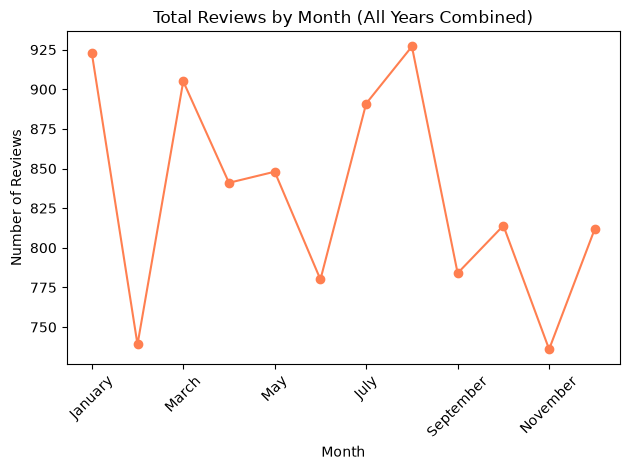

In [21]:
monthly_combined.plot(kind='line', marker='o', color='coral')
plt.title('Total Reviews by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

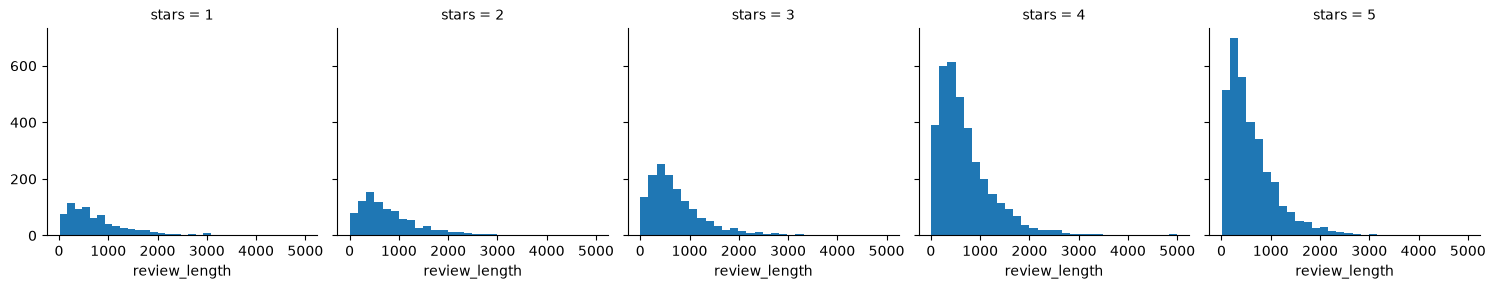

In [22]:
g = sns.FacetGrid(df, col='stars')
g.map(plt.hist, 'review_length', bins=30)

In [29]:
df1=df[['review_length','cool', 'useful', 'funny','stars']]
m=df1.groupby('stars').mean()
round(m,2)

,review_length,cool,useful,funny
stars,,,,
1,826.52,0.58,1.60,1.06
2,842.26,0.72,1.56,0.88
3,758.50,0.79,1.31,0.69
4,712.92,0.95,1.40,0.67
5,625.00,0.94,1.38,0.61
